Cell 1 - Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Cell 2 - Load Cleaned Datasets

In [22]:
branches = pd.read_csv("../data/cleaned/branches.csv")
inventory = pd.read_csv("../data/cleaned/inventory.csv")
products = pd.read_csv("../data/cleaned/products.csv")
stock = pd.read_csv("../data/cleaned/stock_ledger.csv")

Cell 3 - Dataset Overview

In [23]:
datasets = {
    "Branches": branches,
    "Inventory": inventory,
    "Products": products,
    "Stock Ledger": stock
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Branches,6,13
1,Inventory,180,8
2,Products,30,25
3,Stock Ledger,237230,11


Cell 4 - Merge Inventory with Branches

In [24]:
warehouse = inventory.merge(
    branches,
    on="branch_id",
    how="left"
)

warehouse.head()

,product_id,branch_id,opening_stock,reorder_level,safety_stock,max_stock,current_stock,warehouse_bin,branch_name,city,state,region,warehouse_type,warehouse_capacity,service_center_available,manager_id,total_employees,avg_monthly_revenue,monthly_operational_cost,market_demand_index
0,P001,Del001,196,59,46,340,115928,C15,Delhi Central,Delhi,Delhi,North,Central,45230 Sqft,Yes,9593,92,5234890,3189000,9
1,P001,Pun001,198,70,43,349,109389,D16,Pune Distribution,Pune,Maharashtra,West,Regional,38750 Sqft,Yes,6114,74,4389120,2654000,8
2,P001,Chn001,187,62,44,311,99373,A11,Chennai South Hub,Chennai,Tamil Nadu,South,Regional,41890 Sqft,Yes,7922,81,4567780,2739000,8
3,P001,Hyd001,226,71,65,417,108772,A10,Hyderabad Logistics,Hyderabad,Telangana,South,Branch,36210 Sqft,No,4390,57,3102455,1887000,7
4,P001,Kol001,263,94,58,475,103808,F03,Kolkata East Depot,Kolkata,West Bengal,East,Branch,29880 Sqft,No,5981,49,2894770,1743000,6


Cell 5 - Warehouse Stock Summary

In [25]:
warehouse_stock = warehouse.groupby(
    ["branch_name", "city"]
).agg(
    Total_Stock=("current_stock", "sum"),
    Opening_Stock=("opening_stock", "sum"),
    Avg_Current_Stock=("current_stock", "mean")
).reset_index()

warehouse_stock

,branch_name,city,Total_Stock,Opening_Stock,Avg_Current_Stock
0,Ahmedabad West Hub,Ahmedabad,3154992,5444,105166.400000
1,Chennai South Hub,Chennai,3234245,5472,107808.166667
2,Delhi Central,Delhi,3288670,5506,109622.333333
3,Hyderabad Logistics,Hyderabad,3245291,5553,108176.366667
4,Kolkata East Depot,Kolkata,3123805,6063,104126.833333
5,Pune Distribution,Pune,3256263,4931,108542.100000


Cell 6 - Warehouse Capacity

In [26]:
warehouse_capacity = warehouse.groupby(
    "branch_name"
).agg(
    Current_Stock=("current_stock", "sum"),
    Maximum_Stock=("max_stock", "sum")
).reset_index()

warehouse_capacity["Available_Capacity"] = (
    warehouse_capacity["Maximum_Stock"] -
    warehouse_capacity["Current_Stock"]
)

warehouse_capacity

,branch_name,Current_Stock,Maximum_Stock,Available_Capacity
0,Ahmedabad West Hub,3154992,9690,-3145302
1,Chennai South Hub,3234245,9642,-3224603
2,Delhi Central,3288670,9744,-3278926
3,Hyderabad Logistics,3245291,9437,-3235854
4,Kolkata East Depot,3123805,10846,-3112959
5,Pune Distribution,3256263,8557,-3247706


Cell 7 - Warehouse Utilization %

In [27]:
warehouse_capacity["Utilization_%"] = (
    warehouse_capacity["Current_Stock"] /
    warehouse_capacity["Maximum_Stock"]
) * 100

warehouse_capacity = warehouse_capacity.round(2)

warehouse_capacity

,branch_name,Current_Stock,Maximum_Stock,Available_Capacity,Utilization_%
0,Ahmedabad West Hub,3154992,9690,-3145302,32559.26
1,Chennai South Hub,3234245,9642,-3224603,33543.30
2,Delhi Central,3288670,9744,-3278926,33750.72
3,Hyderabad Logistics,3245291,9437,-3235854,34389.01
4,Kolkata East Depot,3123805,10846,-3112959,28801.45
5,Pune Distribution,3256263,8557,-3247706,38053.79


Cell 8 - Highest & Lowest Utilized Warehouses

In [28]:
highest = warehouse_capacity.sort_values(
    by="Utilization_%",
    ascending=False
).head(5)

lowest = warehouse_capacity.sort_values(
    by="Utilization_%"
).head(5)

print("Highest Utilization")
display(highest)

print("Lowest Utilization")
display(lowest)

Highest Utilization


,branch_name,Current_Stock,Maximum_Stock,Available_Capacity,Utilization_%
5,Pune Distribution,3256263,8557,-3247706,38053.79
3,Hyderabad Logistics,3245291,9437,-3235854,34389.01
2,Delhi Central,3288670,9744,-3278926,33750.72
1,Chennai South Hub,3234245,9642,-3224603,33543.30
0,Ahmedabad West Hub,3154992,9690,-3145302,32559.26


Lowest Utilization


,branch_name,Current_Stock,Maximum_Stock,Available_Capacity,Utilization_%
4,Kolkata East Depot,3123805,10846,-3112959,28801.45
0,Ahmedabad West Hub,3154992,9690,-3145302,32559.26
1,Chennai South Hub,3234245,9642,-3224603,33543.30
2,Delhi Central,3288670,9744,-3278926,33750.72
3,Hyderabad Logistics,3245291,9437,-3235854,34389.01


Cell 9 - Visualization

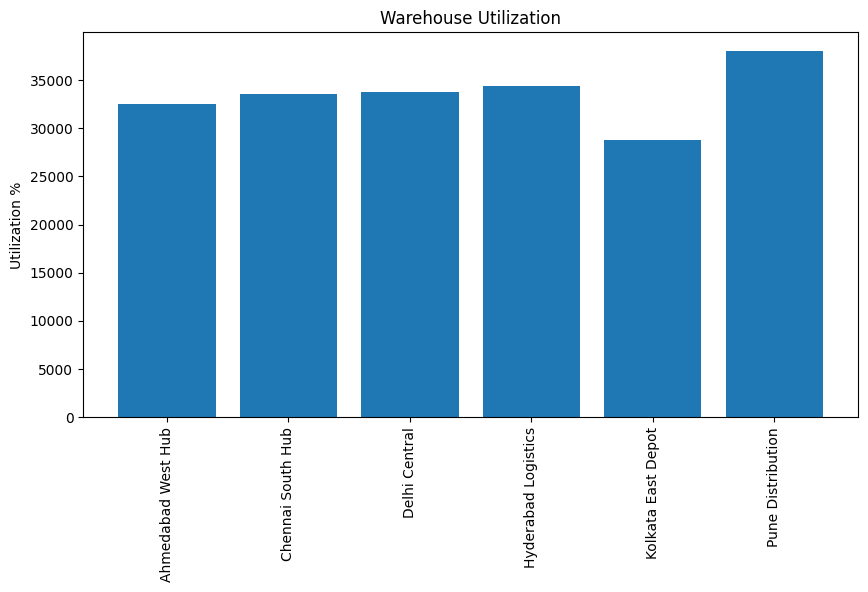

In [29]:
plt.figure(figsize=(10,5))

plt.bar(
    warehouse_capacity["branch_name"],
    warehouse_capacity["Utilization_%"]
)

plt.xticks(rotation=90)

plt.ylabel("Utilization %")

plt.title("Warehouse Utilization")

plt.show()

Cell 10 - Branch-wise Inventory

In [30]:
branch_inventory = warehouse.groupby(
    "branch_name"
)["current_stock"].sum().sort_values(
    ascending=False
)

branch_inventory

branch_name
Delhi Central          3288670
Pune Distribution      3256263
Hyderabad Logistics    3245291
Chennai South Hub      3234245
Ahmedabad West Hub     3154992
Kolkata East Depot     3123805
Name: current_stock, dtype: int64

Cell 11 - Chart

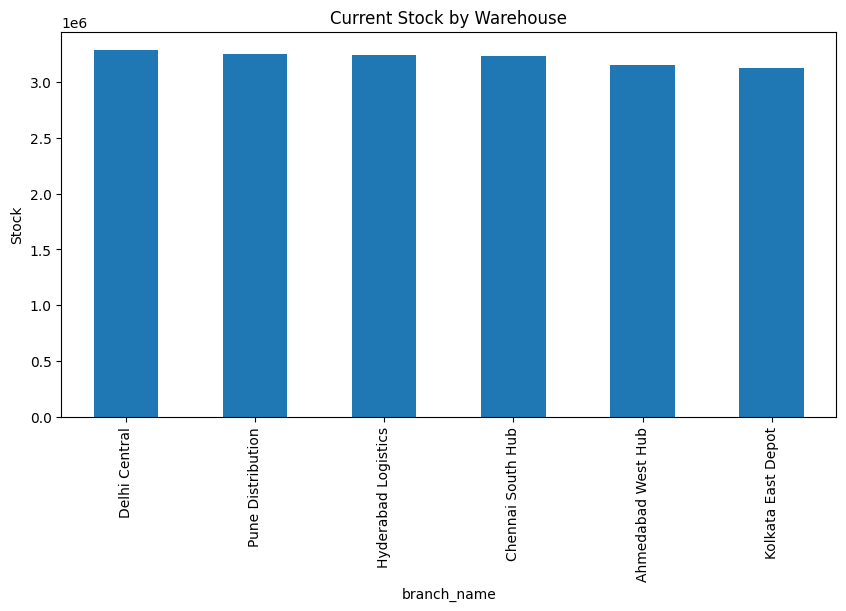

In [31]:
plt.figure(figsize=(10,5))

branch_inventory.plot(kind="bar")

plt.title("Current Stock by Warehouse")

plt.ylabel("Stock")

plt.show()

Cell 12 - Warehouse Type Distribution

In [32]:
branches["warehouse_type"].value_counts()

warehouse_type
Regional       2
Branch         2
Central        1
Service Hub    1
Name: count, dtype: int64

Cell 13 - Chart

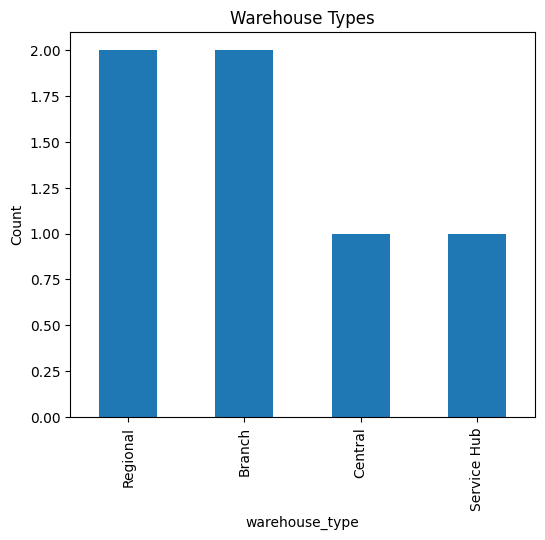

In [33]:
plt.figure(figsize=(6,5))

branches["warehouse_type"].value_counts().plot(
    kind="bar"
)

plt.title("Warehouse Types")

plt.ylabel("Count")

plt.show()

Cell 14 - Employees by Warehouse

In [34]:
branches[[
    "branch_name",
    "total_employees"
]].sort_values(
    by="total_employees",
    ascending=False
)

,branch_name,total_employees
0,Delhi Central,92
2,Chennai South Hub,81
1,Pune Distribution,74
5,Ahmedabad West Hub,63
3,Hyderabad Logistics,57
4,Kolkata East Depot,49


Cell 15 - Revenue vs Operational Cost

In [35]:
financial = branches[[
    "branch_name",
    "avg_monthly_revenue",
    "monthly_operational_cost"
]]

financial

,branch_name,avg_monthly_revenue,monthly_operational_cost
0,Delhi Central,5234890,3189000
1,Pune Distribution,4389120,2654000
2,Chennai South Hub,4567780,2739000
3,Hyderabad Logistics,3102455,1887000
4,Kolkata East Depot,2894770,1743000
5,Ahmedabad West Hub,3245890,2018000


Cell 16 - Revenue Chart

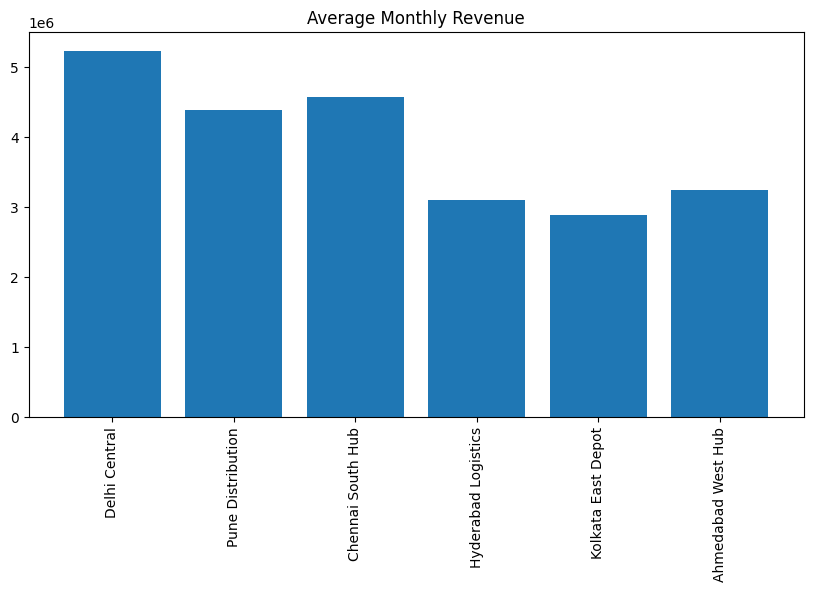

In [36]:
plt.figure(figsize=(10,5))

plt.bar(
    financial["branch_name"],
    financial["avg_monthly_revenue"]
)

plt.xticks(rotation=90)

plt.title("Average Monthly Revenue")

plt.show()

Cell 17 - Stock Movement Summary

In [37]:
stock_summary = stock.groupby("movement_type").agg(
    Total_Quantity=("quantity", "sum"),
    Transactions=("movement_id", "count")
).reset_index()

stock_summary

,movement_type,Total_Quantity,Transactions
0,Adjustment,66990,2454
1,In,20397795,127611
2,Out,1124832,107165


Cell 18 - Stock In vs Stock Out Chart

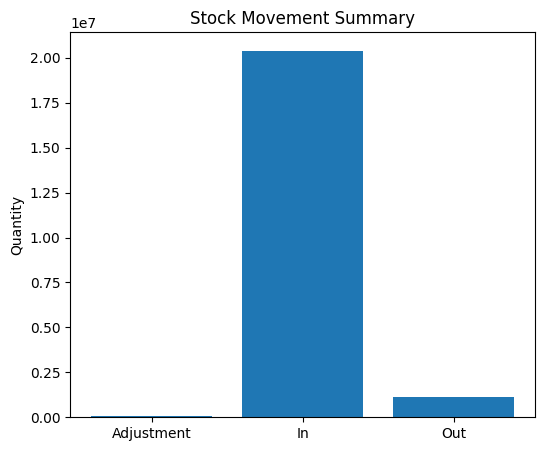

In [38]:
plt.figure(figsize=(6,5))

plt.bar(
    stock_summary["movement_type"],
    stock_summary["Total_Quantity"]
)

plt.title("Stock Movement Summary")
plt.ylabel("Quantity")

plt.show()

Cell 19 - Branch-wise Stock Movement

In [39]:
movement_branch = stock.merge(
    branches,
    on="branch_id",
    how="left"
)

branch_movement = movement_branch.groupby(
    ["branch_name", "movement_type"]
)["quantity"].sum().reset_index()

branch_movement.head()

,branch_name,movement_type,quantity
0,Ahmedabad West Hub,Adjustment,10182
1,Ahmedabad West Hub,In,3344924
2,Ahmedabad West Hub,Out,194742
3,Chennai South Hub,Adjustment,11314
4,Chennai South Hub,In,3461260


Cell 20 - Product Distribution

In [40]:
warehouse_products = inventory.merge(
    products,
    on="product_id",
    how="left"
)

distribution = warehouse_products.groupby(
    "category"
)["current_stock"].sum().sort_values(
    ascending=False
)

distribution

category
Hydraulic        3851410
Undercarriage    2607045
Engine           2584941
Electrical       1903341
Filters          1305127
Seals            1265571
Brakes            663107
Transmission      661663
Belts             659066
Cabin             651781
Sensors           634978
Cooling           633960
Lubricants        631316
Pins & Bushes     625266
Attachments       624694
Name: current_stock, dtype: int64

Cell 21 - Category Distribution Chart

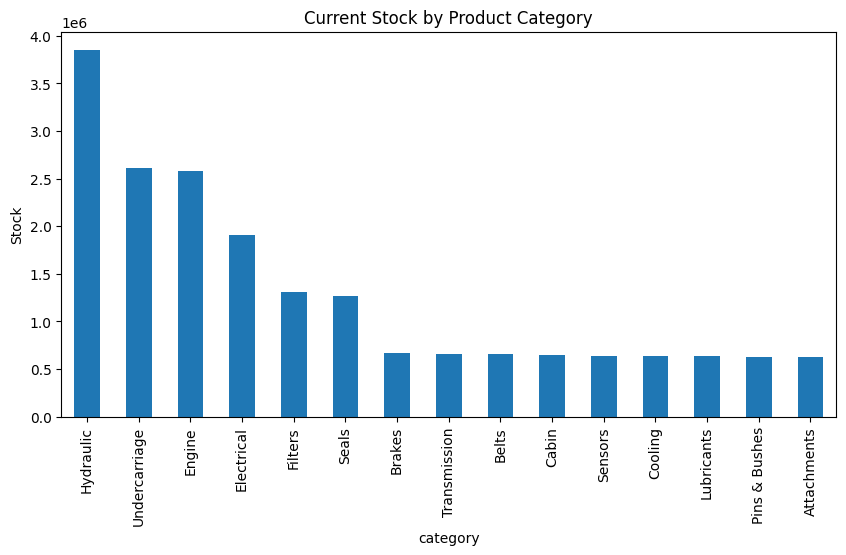

In [41]:
plt.figure(figsize=(10,5))

distribution.plot(kind="bar")

plt.title("Current Stock by Product Category")

plt.ylabel("Stock")

plt.show()

Cell 22 - Products Below Reorder Level

In [42]:
understock = inventory[
    inventory["current_stock"] <
    inventory["reorder_level"]
]

print("Products Below Reorder Level")

understock.head(20)

Products Below Reorder Level


,product_id,branch_id,opening_stock,reorder_level,safety_stock,max_stock,current_stock,warehouse_bin


Cell 23 - Overstock Products

In [43]:
overstock = inventory[
    inventory["current_stock"] >
    inventory["max_stock"]
]

print("Overstock Products")

overstock.head(20)

Overstock Products


,product_id,branch_id,opening_stock,reorder_level,safety_stock,max_stock,current_stock,warehouse_bin
0,P001,Del001,196,59,46,340,115928,C15
1,P001,Pun001,198,70,43,349,109389,D16
2,P001,Chn001,187,62,44,311,99373,A11
3,P001,Hyd001,226,71,65,417,108772,A10
4,P001,Kol001,263,94,58,475,103808,F03
5,P001,Ahm001,236,77,53,455,106714,C20
6,P002,Del001,166,57,35,261,108628,A06
7,P002,Pun001,113,41,27,180,101623,E01
8,P002,Chn001,267,102,76,465,105885,B04
9,P002,Hyd001,219,78,64,383,121013,A02


Cell 24 - Safety Stock Check

In [44]:
safety = inventory[
    inventory["current_stock"] <
    inventory["safety_stock"]
]

print("Products Below Safety Stock")

safety.head(20)

Products Below Safety Stock


,product_id,branch_id,opening_stock,reorder_level,safety_stock,max_stock,current_stock,warehouse_bin


Cell 25 - Operational Bottlenecks

In [45]:
print("Operational Bottlenecks")
print("-"*50)

print("Products Below Reorder Level :", len(understock))

print("Products Above Maximum Stock :", len(overstock))

print("Products Below Safety Stock :", len(safety))

Operational Bottlenecks
--------------------------------------------------
Products Below Reorder Level : 0
Products Above Maximum Stock : 180
Products Below Safety Stock : 0


Cell 26 - Warehouse KPI Dashboard

In [46]:
kpi = pd.DataFrame({

    "Metric":[
        "Total Warehouses",
        "Total Current Stock",
        "Average Warehouse Utilization",
        "Products Below Reorder Level",
        "Products Above Max Stock"
    ],

    "Value":[
        branches["branch_id"].nunique(),
        inventory["current_stock"].sum(),
        round(warehouse_capacity["Utilization_%"].mean(),2),
        len(understock),
        len(overstock)
    ]

})

kpi

,Metric,Value
0,Total Warehouses,6.00
1,Total Current Stock,19303266.00
2,Average Warehouse Utilization,33516.26
3,Products Below Reorder Level,0.00
4,Products Above Max Stock,180.00


Cell 27 - Top Warehouses by Revenue

In [47]:
branches.sort_values(
    by="avg_monthly_revenue",
    ascending=False
)[[
    "branch_name",
    "city",
    "avg_monthly_revenue"
]].head(10)

,branch_name,city,avg_monthly_revenue
0,Delhi Central,Delhi,5234890
2,Chennai South Hub,Chennai,4567780
1,Pune Distribution,Pune,4389120
5,Ahmedabad West Hub,Ahmedabad,3245890
3,Hyderabad Logistics,Hyderabad,3102455
4,Kolkata East Depot,Kolkata,2894770


Cell 28 - Business Insights

In [48]:
print("BUSINESS INSIGHTS")

print("-"*60)

print(f"Total Warehouses : {branches['branch_id'].nunique()}")

print(f"Current Stock : {inventory['current_stock'].sum():,.0f}")

print(f"Average Warehouse Utilization : {warehouse_capacity['Utilization_%'].mean():.2f}%")

print(f"Products Below Reorder Level : {len(understock)}")

print(f"Products Below Safety Stock : {len(safety)}")

print(f"Overstock Products : {len(overstock)}")

BUSINESS INSIGHTS
------------------------------------------------------------
Total Warehouses : 6
Current Stock : 19,303,266
Average Warehouse Utilization : 33516.26%
Products Below Reorder Level : 0
Products Below Safety Stock : 0
Overstock Products : 180


Cell 29 - Recommendations

In [49]:
recommendations = [

    "Increase stock for products below reorder level.",

    "Reduce excess inventory in overstocked products.",

    "Monitor warehouses with utilization above 90%.",

    "Improve inventory balancing across branches.",

    "Optimize warehouse operational costs."

]

for i, rec in enumerate(recommendations,1):

    print(f"{i}. {rec}")

1. Increase stock for products below reorder level.
2. Reduce excess inventory in overstocked products.
3. Monitor warehouses with utilization above 90%.
4. Improve inventory balancing across branches.
5. Optimize warehouse operational costs.


Cell 30 - Final Summary

In [50]:
summary = pd.DataFrame({

    "Analysis":[
        "Warehouse Utilization",
        "Capacity Analysis",
        "Stock Movement",
        "Product Distribution",
        "Operational Bottlenecks"
    ],

    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]

})

summary

,Analysis,Status
0,Warehouse Utilization,Completed
1,Capacity Analysis,Completed
2,Stock Movement,Completed
3,Product Distribution,Completed
4,Operational Bottlenecks,Completed
